 1.Import libraries
 -Data manipulation and analysis 
 -Connects Python to PostgreSQL database
 -Loads variables from .env file 
 -Access environment variables (os.getenv)

In [3]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

2. Connexion a la base de donnees
- Charge les variables du fichier .env
- Cree le moteur de connexion vers PostgreSQL

In [4]:
load_dotenv()

engine = create_engine(os.getenv("DATABASE_URL"))

print("Connexion configuree avec succes.")

Connexion configuree avec succes.


3.Chargement des donnees (orders)

Cette cellule recupere les colonnes necessaires depuis la table `orders` :
- wilaya_normalized
- order_total_amount
- customer_id_stage
- order_date
- order_status

In [5]:
query = """
SELECT wilaya_normalized, order_total_amount, customer_id_stage, order_date, order_status
FROM orders
"""

df_orders = pd.read_sql(query, engine)

df_orders.shape 

(9245, 5)

 4. Apercu des donnees

Affichage des premieres lignes et des types de colonnes pour verifier que les donnees sont bien chargees.

In [6]:
df_orders.head(10)

,wilaya_normalized,order_total_amount,customer_id_stage,order_date,order_status
0,Oran,4975.0,CLT_S04622,2021-10-03,Terminée
1,Annaba,2681.0,CLT_S01357,2021-10-04,Terminée
2,M'Sila,14504.0,CLT_S04465,2021-10-05,Terminée
3,Alger,15273.0,CLT_S01372,2021-10-07,Terminée
4,Alger,2294.0,CLT_S02042,2021-10-18,Terminée
5,Alger,34496.0,CLT_S04703,2021-10-22,Terminée
6,Alger,55872.0,CLT_S04703,2021-10-22,Terminée
7,Oran,8043.0,CLT_S04622,2021-11-03,Terminée
8,Alger,2294.0,CLT_S00018,2021-11-11,Terminée
9,Béchar,11552.0,CLT_S04749,2021-11-14,Terminée


5. Types des colonnes

Verification des types de donnees (texte, nombre, date...) pour chaque colonne.

In [7]:
df_orders.dtypes

wilaya_normalized                str
order_total_amount           float64
customer_id_stage                str
order_date            datetime64[us]
order_status                     str
dtype: object

6. Revenue par wilaya

Calcul du chiffre d'affaires total pour chaque wilaya, en regroupant les commandes.

In [8]:
revenue_per_wilaya = (
    df_orders
    .groupby("wilaya_normalized")["order_total_amount"]
    .sum()
    .reset_index()
    .sort_values("order_total_amount", ascending=False)
)

revenue_per_wilaya

,wilaya_normalized,order_total_amount
1,Alger,86202600.07
56,Tlemcen,27719465.87
8,Blida,14383791.24
39,Oran,13861478.89
55,Tizi Ouzou,12841627.86
50,Tiaret,12425678.16
48,Sétif,11097174.51
11,Boumerdès,10909400.16
53,Tipaza,7964071.00
6,Batna,7038876.30


7. Nombre de clients actifs par wilaya

Comptage du nombre de clients uniques ayant passe au moins une commande, pour chaque wilaya.

In [9]:
active_customers_per_wilaya = (
    df_orders
    .groupby("wilaya_normalized")["customer_id_stage"]
    .nunique()
    .reset_index()
    .rename(columns={"customer_id_stage": "active_customers"})
    .sort_values("active_customers", ascending=False)
)

active_customers_per_wilaya

,wilaya_normalized,active_customers
1,Alger,1180
39,Oran,241
56,Tlemcen,214
8,Blida,176
2,Annaba,164
55,Tizi Ouzou,149
16,Constantine,146
11,Boumerdès,145
46,Skikda,142
13,Béjaïa,140


8. Fusion des deux tableaux (Wilaya Ranking complet)

Combinaison du revenue et du nombre de clients actifs dans un seul tableau, 
avec calcul du revenu moyen par client pour chaque wilaya.

In [10]:
wilaya_ranking = revenue_per_wilaya.merge(
    active_customers_per_wilaya,
    on="wilaya_normalized"
)

wilaya_ranking["avg_revenue_per_customer"] = (
    wilaya_ranking["order_total_amount"] / wilaya_ranking["active_customers"]
)

wilaya_ranking = wilaya_ranking.sort_values("order_total_amount", ascending=False)

wilaya_ranking

,wilaya_normalized,order_total_amount,active_customers,avg_revenue_per_customer
0,Alger,86202600.07,1180,73053.050907
1,Tlemcen,27719465.87,214,129530.214346
2,Blida,14383791.24,176,81726.086591
3,Oran,13861478.89,241,57516.509917
4,Tizi Ouzou,12841627.86,149,86185.421879
5,Tiaret,12425678.16,71,175009.551549
6,Sétif,11097174.51,131,84711.255802
7,Boumerdès,10909400.16,145,75237.242483
8,Tipaza,7964071.00,103,77321.077670
9,Batna,7038876.30,133,52923.881955


 9. Visualisation : Top 10 wilayas par revenue

Graphique en barres montrant les 10 wilayas generant le plus de chiffre d'affaires.

In [11]:
import matplotlib.pyplot as plt

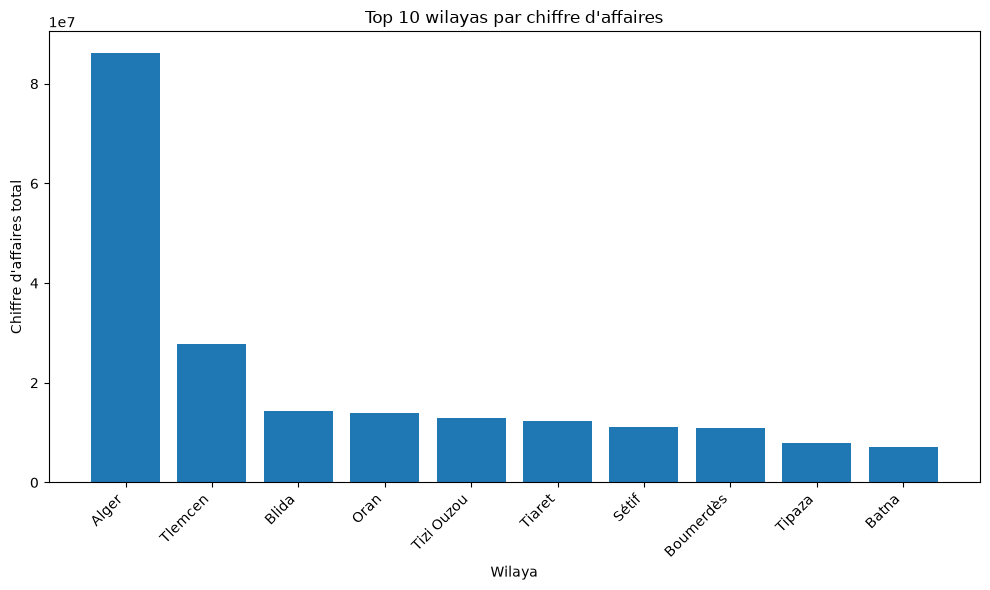

In [12]:
top10 = wilaya_ranking.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10["wilaya_normalized"], top10["order_total_amount"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Wilaya")
plt.ylabel("Chiffre d'affaires total")
plt.title("Top 10 wilayas par chiffre d'affaires")
plt.tight_layout()
plt.show()

10. Wilayas a risque (baisse des ventes)

Comparaison des ventes entre deux periodes pour identifier les wilayas 
dont le chiffre d'affaires est en baisse.

In [14]:
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])

date_max = df_orders["order_date"].max()
date_max

Timestamp('2026-07-19 00:00:00')

11. Definition des deux periodes de comparaison

Periode recente : les 3 derniers mois
Periode precedente : les 3 mois avant celle-ci

In [15]:
recent_start = date_max - pd.DateOffset(months=3)
previous_start = date_max - pd.DateOffset(months=6)

df_recent = df_orders[df_orders["order_date"] >= recent_start]
df_previous = df_orders[
    (df_orders["order_date"] >= previous_start) &
    (df_orders["order_date"] < recent_start)
]

df_recent.shape, df_previous.shape

((877, 5), (857, 5))